In [1]:
print("Hello World")

Hello World


In [2]:
print("time for machine learning")

time for machine learning


In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [4]:
df= pd.read_csv("bike_prices_dataset.csv")
df.head()

,S.no,Bike_company,Bike_model,Manufactured_year,Engine_warranty,Engine_type,Fuel_type,CC(Cubic capacity),Fuel_Capacity,Price
0,1,Bajaj,Avenger 220,2020,5.0,Single,Petrol,220CC,10 Litres,113000
1,2,TVS,Apache RTR,2020,5.0,V-twin,Petrol,120CC,11 Litres,70000
2,3,Hero,Passion,2020,5.0,Boxer,Petrol,140CC,12 Litres,85000
3,4,Honda,Activa 3G,2020,5.0,Single,Petrol,150CC,13 Litres,90000
4,5,Suzuki,Access,2020,5.0,V-twin,Petrol,350CC,14 Litres,65000


In [5]:
df.tail()


,S.no,Bike_company,Bike_model,Manufactured_year,Engine_warranty,Engine_type,Fuel_type,CC(Cubic capacity),Fuel_Capacity,Price
303,304,Bgauss,Bgauss B8,2017,3.0,Boxer,Petrol,185CC,19 Litres,81916
304,305,Bgauss,Bgauss Radiator,2017,3.0,Boxer,Petrol,205CC,20 Litres,82666
305,306,Bgauss,Bgauss Razor,2017,3.0,Boxer,Petrol,185CC,21 Litres,83416
306,307,Bgauss,Bgauss Flash,2017,3.0,Boxer,Petrol,205CC,22 Litres,84166
307,308,Bgauss,Bgauss Hash,2017,3.0,Boxer,Petrol,220CC,23 Litres,84916


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   S.no                308 non-null    int64  
 1   Bike_company        308 non-null    object 
 2   Bike_model          308 non-null    object 
 3   Manufactured_year   308 non-null    int64  
 4   Engine_warranty     306 non-null    float64
 5   Engine_type         308 non-null    object 
 6   Fuel_type           308 non-null    object 
 7   CC(Cubic capacity)  308 non-null    object 
 8   Fuel_Capacity       307 non-null    object 
 9   Price               308 non-null    int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 24.2+ KB


In [7]:
df.isna()
df =df.rename(columns={"CC(Cubic capacity)": "cubic_capacity",})

In [8]:
df.duplicated()
df['Fuel_Capacity'] = df['Fuel_Capacity'].str.replace("Litres","")
df[df['Fuel_Capacity'] == "Battery"]

,S.no,Bike_company,Bike_model,Manufactured_year,Engine_warranty,Engine_type,Fuel_type,cubic_capacity,Fuel_Capacity,Price
14,15,Lectro Electric,Gold,2020,2.0,Boxer,Electricity,120CC,Battery,65000
15,16,Li-ion Elektrik Solution,Silver,2020,2.0,Two-Stroke,Electricity,150CC,Battery,69000
16,17,Ather Energy,Energitic,2020,4.0,Two-Stroke,Electricity,130CC,Battery,73000
31,32,Lectro Electric,Leon,2014,2.0,Single,Electricity,120CC,Battery,62000
32,33,Li-ion Elektrik Solution,Ceon,2015,2.0,Single,Electricity,130CC,Battery,65000
33,34,Lectro Electric,Neon,1840,2.0,Single,Electricity,145CC,Battery,79000
73,74,Li-ion Elektrik Solution,Ceon,2016,2.0,Single,Electricity,130CC,Battery,65000
74,74,Li-ion Elektrik Solution,Prime,2017,3.0,Single,Electricity,125CC,Battery,61000
75,76,Li-ion Elektrik Solution,Power,2019,50.0,V-twin,Electricity,130CC,Battery,56700
76,77,Li-ion Elektrik Solution,Kurrent,2019,3.0,V-twin,Electricity,135CC,Battery,61000


In [9]:
df['Fuel_Capacity'] = df['Fuel_Capacity'].str.extract(r'(\d+\.?\d*)').astype(dtype=float)

df[df['Fuel_type'] == "Electricity"]


,S.no,Bike_company,Bike_model,Manufactured_year,Engine_warranty,Engine_type,Fuel_type,cubic_capacity,Fuel_Capacity,Price
14,15,Lectro Electric,Gold,2020,2.0,Boxer,Electricity,120CC,NaN,65000
15,16,Li-ion Elektrik Solution,Silver,2020,2.0,Two-Stroke,Electricity,150CC,NaN,69000
16,17,Ather Energy,Energitic,2020,4.0,Two-Stroke,Electricity,130CC,NaN,73000
31,32,Lectro Electric,Leon,2014,2.0,Single,Electricity,120CC,NaN,62000
32,33,Li-ion Elektrik Solution,Ceon,2015,2.0,Single,Electricity,130CC,NaN,65000
33,34,Lectro Electric,Neon,1840,2.0,Single,Electricity,145CC,NaN,79000
34,35,Mahindra,Gutter,2020,5.0,Single,Electricity,135CC,16.0,65000
36,37,Mahindra,Shutter,2018,5.0,Single,Electricity,135CC,18.0,68000
73,74,Li-ion Elektrik Solution,Ceon,2016,2.0,Single,Electricity,130CC,NaN,65000
74,74,Li-ion Elektrik Solution,Prime,2017,3.0,Single,Electricity,125CC,NaN,61000


In [10]:
df.fillna({'Fuel_Capacity': 0}, inplace=True)
df['Is_Electric'] = df['Fuel_type'] == "Electricity"
df.head()

,S.no,Bike_company,Bike_model,Manufactured_year,Engine_warranty,Engine_type,Fuel_type,cubic_capacity,Fuel_Capacity,Price,Is_Electric
0,1,Bajaj,Avenger 220,2020,5.0,Single,Petrol,220CC,10.0,113000,False
1,2,TVS,Apache RTR,2020,5.0,V-twin,Petrol,120CC,11.0,70000,False
2,3,Hero,Passion,2020,5.0,Boxer,Petrol,140CC,12.0,85000,False
3,4,Honda,Activa 3G,2020,5.0,Single,Petrol,150CC,13.0,90000,False
4,5,Suzuki,Access,2020,5.0,V-twin,Petrol,350CC,14.0,65000,False


In [11]:
df['cubic_capacity'] = df['cubic_capacity'].str.replace("CC","").astype(dtype=int)
df['Bike_model'].nunique()


237

In [12]:
df_enocded = pd.get_dummies(df, drop_first= True, columns=["Engine_type", "Fuel_type", "Is_Electric","Bike_company"],dtype= int)
df_enocded.head()


,S.no,Bike_model,Manufactured_year,Engine_warranty,cubic_capacity,Fuel_Capacity,Price,Engine_type_Dual Stroke,Engine_type_Oxidiser-Air inlet,Engine_type_Single,...,Bike_company_Li-ion Elektrik Solution,Bike_company_Mahindra,Bike_company_Odysse,Bike_company_Okinawa,Bike_company_Revolt Motors,Bike_company_Royal Enfield,Bike_company_Suzuki,Bike_company_TVS,Bike_company_Triumph,Bike_company_Yamaha
0,1,Avenger 220,2020,5.0,220,10.0,113000,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,2,Apache RTR,2020,5.0,120,11.0,70000,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Passion,2020,5.0,140,12.0,85000,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,Activa 3G,2020,5.0,150,13.0,90000,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,5,Access,2020,5.0,350,14.0,65000,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [13]:
from sklearn.model_selection import train_test_split
df_enocded = df_enocded.dropna()

In [14]:
print(df_enocded.isna().sum())

S.no                                     0
Bike_model                               0
Manufactured_year                        0
Engine_warranty                          0
cubic_capacity                           0
Fuel_Capacity                            0
Price                                    0
Engine_type_Dual Stroke                  0
Engine_type_Oxidiser-Air inlet           0
Engine_type_Single                       0
Engine_type_Two-Stroke                   0
Engine_type_V-twin                       0
Fuel_type_Petrol                         0
Is_Electric_True                         0
Bike_company_Ather Energy                0
Bike_company_BMW                         0
Bike_company_Bajaj                       0
Bike_company_Banelli                     0
Bike_company_Bgauss                      0
Bike_company_CFMoto                      0
Bike_company_Ducati                      0
Bike_company_Harley Davidson             0
Bike_company_Hero                        0
Bike_compan

In [15]:
y = df_enocded["Price"].to_numpy()
X = df_enocded.drop(["Price", "S.no","Bike_model"],axis= 1).to_numpy()

print(y)

[ 113000   70000   85000   90000   65000  180000   65000  150000   89000
   99999  250000  350000  130000  340000   65000   69000   73000   89000
   99000   74000   79999   87999  185999   90000   55000  350000  459999
  330000  449090  529999   62000   65000   79000   65000   70000   68000
   77990   89000  189000  240000  300000  358999  550000  590000  623000
  650000  890000  990000 1200000 1234500  679999  549999  767888  898999
  124500  145000  219500  232000  124500  135000   70000   64000   79999
   75000   89000  125000   75000   77000   81000   55000   56700   61000
   65000   61000   56700   61000   65000   65000   90000   62000  250000
   61000   66700   71000   65000   65000  260000  219500  232000  124500
  260000  219500  232000  450000  650000  790000  103000  101000  650000
  790000  103000  124500  134500   64500   65000   79000  103000  101000
  650000  790000  103000  124500  134500  790000  103000  124500  134500
  650000  790000  950000  990000  790000  950000  1

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

print(np.isnan(X_train))

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


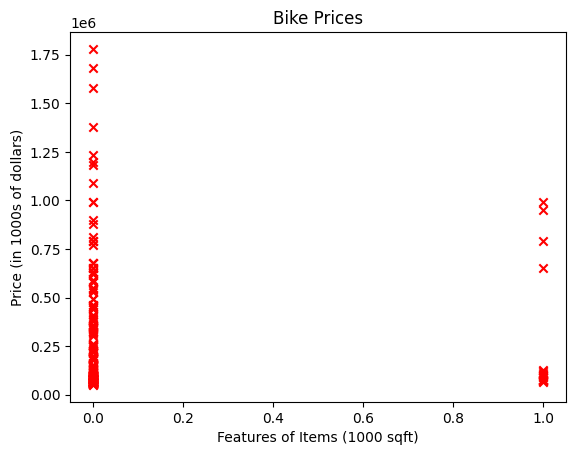

In [17]:
plt.scatter(X_train[:, 7],y_train,marker='x', c='r')
# Set the title
plt.title("Bike Prices")
# Set the y-axis label
plt.ylabel('Price (in 1000s of dollars)')
# Set the x-axis label
plt.xlabel('Features of Items (1000 sqft)')
plt.show()

In [18]:
print(X_train.shape)
print(len(X_train[0]))

(244, 35)
35


In [19]:

n_features = X_train.shape[1]
print(f"Number of features: {n_features}")

# Re-initialize w with the correct size
w = np.random.randn(n_features) * 0.01
b = 0.0

print(f"w shape: {w.shape}")
print(f"X_train shape: {X_train.shape}")

Number of features: 35
w shape: (35,)
X_train shape: (244, 35)


In [20]:
def predict(x, w, b): 
    p = np.dot(x, w) + b     
    return p    

In [21]:
# make a prediction
f_wb = predict(X_train,w, b)
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")

f_wb shape (244,), prediction: [ -8.58959783  -8.94292869  -8.47647675  -8.48922615  -8.81001251
  -9.67480881  -8.49240256 -10.9102466   -8.43929657  -8.69276181
 -10.19086951  -8.98529327  -9.14506497  -8.92547223  -8.45922042
  -9.12660792  -8.51607278  -8.4949897   -8.87523924  -9.01621292
  -8.64229573  -8.49173668  -9.36509722  -8.53176025  -8.50009269
  -8.47798269  -8.52569879  -8.44131706  -9.22661254  -8.47571678
  -8.4396147   -8.4980722   -8.8671573   -8.54217916  -8.95403431
  -8.54422537  -8.56614923  -8.69653602  -8.55378619  -8.46774151
  -8.49613713  -8.55167927  -8.59766609  -8.50584281  -8.87961934
  -8.47840853  -8.43556144  -9.12277868  -8.56527988  -9.03392413
  -8.46236117  -8.56185494  -8.58897364  -8.53337147  -8.49038207
  -8.69318142  -8.93551313  -9.63310622  -8.56994964  -9.43732721
 -10.03515766  -8.477717    -8.40431188  -9.54711641  -8.77565344
  -8.71708135  -8.63987025  -8.91035104  -8.75343165  -8.54552223
  -8.71007127  -8.56836387  -8.45407775  -8.7

In [22]:
def compute_cost(X, y, w, b): 
    """
    compute cost
    Args:
      X (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)) : target values
      w (ndarray (n,)) : model parameters  
      b (scalar)       : model parameter
      
    Returns:
      cost (scalar): cost
    """
    m = X.shape[0]
    cost = 0.0
    for i in range(m):                                
        f_wb_i = np.dot(X[i], w) + b           #(n,)(n,) = scalar (see np.dot)
        cost = cost + (f_wb_i - y[i])**2       #scalar
    cost = cost / (2 * m)                      #scalar    
    return cost

In [23]:
# Compute and display cost using our pre-chosen optimal parameters. 
cost = compute_cost(X_train, y_train, w, b)
print(f'Current Cost : {cost}')

Current Cost : 81465960141.35133


In [24]:
def compute_gradient(X,y, w, b):
    """
    Computes the gradient for linear regression 
    Args:
      x (ndarray (m,)): Data, m examples 
      y (ndarray (m,)): target values
      w,b (scalar)    : model parameters  
    Returns
      dj_dw (scalar): The gradient of the cost w.r.t. the parameters w
      dj_db (scalar): The gradient of the cost w.r.t. the parameter b     
     """
    m = X.shape[0]
    dj_dw = np.zeros(X.shape[1])
    dj_db = 0

    for i in range(m):  
        f_wb = np.dot(X[i], w) + b
        dj_dw_i = (f_wb - y[i]) * X[i] 
        dj_db_i = f_wb - y[i] 
        dj_db += dj_db_i
        dj_dw += dj_dw_i 
    dj_dw = dj_dw / m 
    dj_db = dj_db / m 
        
    return dj_dw, dj_db
    

In [25]:
import math, copy

In [26]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function): 
    """
    Performs gradient descent to fit w,b. Updates w,b by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      x (ndarray (m,))  : Data, m examples 
      y (ndarray (m,))  : target values
      w_in,b_in (scalar): initial values of model parameters  
      alpha (float):     Learning rate
      num_iters (int):   number of iterations to run gradient descent
      cost_function:     function to call to produce cost
      gradient_function: function to call to produce gradient
      
    Returns:
      w (scalar): Updated value of parameter after running gradient descent
      b (scalar): Updated value of parameter after running gradient descent
      J_history (List): History of cost values
      p_history (list): History of parameters [w,b] 
      """
    
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    p_history = []
    b = b_in
    w = w_in
    
    for i in range(num_iters):
        # Calculate the gradient and update the parameters using gradient_function
        dj_dw, dj_db = gradient_function(x, y, w , b)     

        # Update Parameters using equation (3) above
        b = b - alpha * dj_db                            
        w = w - alpha * dj_dw                            

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append( cost_function(x, y, w , b))
            p_history.append([w,b])
        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0:
            p_history.append(w.copy())
            print(f"Iteration {i}: Cost {float(J_history[-1]):8.2f}   ")
 
    return w, b, J_history, p_history #return w and J,w history for graphing

In [44]:
# some gradient descent settings
iterations = 10000
tmp_alpha = 0.000000000001
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(X_train ,y_train, w, b, tmp_alpha, 
                                                    iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final},{b_final:8.4f})")

Iteration 0: Cost 81465660976.97   
Iteration 1000: Cost 81167723622.93   
Iteration 2000: Cost 80872224356.68   
Iteration 3000: Cost 80579143038.52   
Iteration 4000: Cost 80288459695.15   
Iteration 5000: Cost 80000154518.27   
Iteration 6000: Cost 79714207863.21   
Iteration 7000: Cost 79430600247.63   
Iteration 8000: Cost 79149312350.10   
Iteration 9000: Cost 78870325008.85   
(w,b) found by gradient descent: ([ 5.18087924e+00  1.78025496e-02  1.35070318e+00  5.16350635e-02
  1.42251933e-02 -1.07183208e-02  1.50539402e-03 -1.10260063e-03
 -1.11697528e-02  1.11910008e-02 -1.51008887e-02  4.32706282e-03
  2.34743828e-02 -1.00080995e-03 -2.32913702e-03 -4.15057882e-03
 -1.20917654e-02 -1.45467918e-02 -4.04664506e-03  8.33474806e-03
  7.92430300e-03  7.70081484e-03  2.51573674e-03 -2.39238369e-03
 -1.78227002e-02  9.93377402e-03  2.31329183e-03  1.61500428e-02
 -4.94012485e-03  4.84514908e-03  1.36956697e-02  8.81892806e-03
  5.81217971e-03  3.66988115e-03  2.29687676e-02],  0.0026)

In [ ]:

def standardize_data(X_train, X_test):
     """
    Standardizes the input data using mean and standard deviation.

    Parameters:
        X_train (numpy.ndarray): Training data.
        X_test (numpy.ndarray): Testing data.

    Returns:
        Tuple of standardized training and testing data.
    """
     
     mean = np.mean(X_train, axis= 0)
     std = np.std(X_train,axis=0)


     X_train = (X_train - mean)/std

     X_test = (X_test - mean)/std

     return X_train, X_test


X_train , X_test = standardize_data(X_train,X_test)
print(X_train)


[[ 0.0941391   0.95982705 -0.53190938 ... -0.17186002 -0.24671758
  -0.26490647]
 [ 0.08562225  0.45833283  0.16752791 ... -0.17186002 -0.24671758
  -0.26490647]
 [ 0.08562225 -0.79540271 -0.74386008 ... -0.17186002 -0.24671758
  -0.26490647]
 ...
 [ 0.08562225 -0.5446556  -0.46832417 ... -0.17186002 -0.24671758
   3.77491722]
 [ 0.0941391   0.45833283 -0.34115376 ... -0.17186002 -0.24671758
  -0.26490647]
 [ 0.0941391  -0.79540271 -0.46832417 ... -0.17186002 -0.24671758
  -0.26490647]]
